In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# CELL 02 — Imports
# ============================================================

import os
import json
import math
import random
import warnings
from dataclasses import dataclass
from typing import Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# CELL 03 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

DATA_PROCESSED_DIR = f"{PROJECT_ROOT}/data_processed"
OUTPUTS_DATA_ANALYSIS_DIR = f"{PROJECT_ROOT}/outputs/data_analysis"
OUTPUTS_BENCHMARK_5Y_DIR = f"{PROJECT_ROOT}/outputs/benchmark_outputs_5y"
OUTPUTS_MODEL_DIR = f"{PROJECT_ROOT}/outputs/model_outputs"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

for path in [
    DATA_PROCESSED_DIR,
    OUTPUTS_DATA_ANALYSIS_DIR,
    OUTPUTS_BENCHMARK_5Y_DIR,
    OUTPUTS_MODEL_DIR,
    CONFIGS_DIR,
]:
    os.makedirs(path, exist_ok=True)

with open(f"{CONFIGS_DIR}/master_config.json", "r") as f:
    master_cfg = json.load(f)

with open(f"{CONFIGS_DIR}/feature_columns.json", "r") as f:
    feature_cfg = json.load(f)

ASSETS = master_cfg["assets"]
LOOKBACK = master_cfg["lookback"]
SEED = master_cfg["seed"]
PERIOD_5Y = master_cfg["period_5y"]
FEATURE_COLS = feature_cfg["feature_columns"]

TRANSACTION_COST = 0.001

np.random.seed(SEED)
random.seed(SEED)

print("ASSETS:", ASSETS)
print("LOOKBACK:", LOOKBACK)
print("N_FEATURES:", len(FEATURE_COLS))
print("TRANSACTION_COST:", TRANSACTION_COST)

ASSETS: ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']
LOOKBACK: 20
N_FEATURES: 13
TRANSACTION_COST: 0.001


In [5]:
# ============================================================
# CELL 04 — Load backbone files
# ============================================================

panel_5y = pd.read_csv(f"{DATA_PROCESSED_DIR}/panel_5y.csv")
panel_5y["date"] = pd.to_datetime(panel_5y["date"])

bundle_5y_npz = np.load(f"{DATA_PROCESSED_DIR}/tensor_bundle_5y.npz", allow_pickle=True)

X_raw = bundle_5y_npz["X"].astype(np.float32)
y = bundle_5y_npz["y"].astype(np.float32)
dates = pd.to_datetime(bundle_5y_npz["dates"])
splits = bundle_5y_npz["splits"]
assets_from_bundle = bundle_5y_npz["assets"]
feature_cols_from_bundle = bundle_5y_npz["feature_cols"]

print("panel_5y:", panel_5y.shape)
print("X_raw:", X_raw.shape)
print("y:", y.shape)
print("dates:", dates.shape)
print("splits:", splits.shape)
print("assets_from_bundle:", assets_from_bundle)
print("feature_cols_from_bundle:", feature_cols_from_bundle)

panel_5y: (6185, 25)
X_raw: (1218, 20, 5, 13)
y: (1218, 5)
dates: (1218,)
splits: (1218,)
assets_from_bundle: ['AAPL' 'MSFT' 'AMZN' 'JPM' 'JNJ']
feature_cols_from_bundle: ['ret_1' 'log_ret_1' 'ret_5' 'ret_10' 'vol_5' 'vol_10' 'vol_20'
 'ma_ratio_5' 'ma_ratio_10' 'ma_ratio_20' 'high_low_spread'
 'open_close_spread' 'volume_z_20']


In [6]:
# ============================================================
# CELL 05 — Backbone sanity checks
# ============================================================

assert X_raw.shape[1] == LOOKBACK
assert X_raw.shape[2] == len(ASSETS)
assert X_raw.shape[3] == len(FEATURE_COLS)
assert y.shape[1] == len(ASSETS)

assert list(assets_from_bundle) == ASSETS
assert list(feature_cols_from_bundle) == FEATURE_COLS

assert set(np.unique(splits)) <= {"train", "val", "test"}

print("Backbone sanity checks passed.")
print("Unique splits:", np.unique(splits, return_counts=True))

Backbone sanity checks passed.
Unique splits: (array(['test', 'train', 'val'], dtype='<U5'), array([251, 717, 250]))


In [7]:
# ============================================================
# CELL 06 — Fit scaler on TRAIN only
# ============================================================

train_mask = (splits == "train")
val_mask = (splits == "val")
test_mask = (splits == "test")

X_train_raw = X_raw[train_mask]

scaler = StandardScaler()

train_flat = X_train_raw.reshape(-1, X_train_raw.shape[-1])
scaler.fit(train_flat)

print("Scaler fitted on TRAIN only.")
print("train_flat shape:", train_flat.shape)
print("scaler mean shape:", scaler.mean_.shape)
print("scaler scale shape:", scaler.scale_.shape)

Scaler fitted on TRAIN only.
train_flat shape: (71700, 13)
scaler mean shape: (13,)
scaler scale shape: (13,)


In [8]:
# ============================================================
# CELL 07 — Apply standardization to all splits
# ============================================================

def apply_scaler_to_4d_tensor(X_4d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    original_shape = X_4d.shape
    flat = X_4d.reshape(-1, original_shape[-1])
    flat_scaled = scaler.transform(flat)
    return flat_scaled.reshape(original_shape).astype(np.float32)

X_scaled = apply_scaler_to_4d_tensor(X_raw, scaler)

print("X_scaled shape:", X_scaled.shape)
print("Train mean approx:", float(X_scaled[train_mask].mean()))
print("Train std approx:", float(X_scaled[train_mask].std()))

X_scaled shape: (1218, 20, 5, 13)
Train mean approx: 6.417171238837227e-09
Train std approx: 0.9999999403953552


In [9]:
# ============================================================
# CELL 08 — Save standardized tensor bundle
# ============================================================

np.savez_compressed(
    f"{DATA_PROCESSED_DIR}/tensor_bundle_5y_standardized.npz",
    X=X_scaled,
    y=y,
    dates=np.array(dates.astype(str)),
    splits=splits,
    assets=np.array(ASSETS),
    feature_cols=np.array(FEATURE_COLS),
)

scaler_artifact = {
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
    "feature_cols": FEATURE_COLS,
}

with open(f"{DATA_PROCESSED_DIR}/scaler_5y.json", "w") as f:
    json.dump(scaler_artifact, f, indent=2)

print("Saved:", f"{DATA_PROCESSED_DIR}/tensor_bundle_5y_standardized.npz")
print("Saved:", f"{DATA_PROCESSED_DIR}/scaler_5y.json")

Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/tensor_bundle_5y_standardized.npz
Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/scaler_5y.json


In [10]:
# ============================================================
# CELL 09 — Split standardized tensors
# ============================================================

data_5y = {
    "train": {
        "X": X_scaled[train_mask],
        "y": y[train_mask],
        "dates": np.array(dates[train_mask].astype(str)),
    },
    "val": {
        "X": X_scaled[val_mask],
        "y": y[val_mask],
        "dates": np.array(dates[val_mask].astype(str)),
    },
    "test": {
        "X": X_scaled[test_mask],
        "y": y[test_mask],
        "dates": np.array(dates[test_mask].astype(str)),
    }
}

for split_name in ["train", "val", "test"]:
    print(
        split_name,
        data_5y[split_name]["X"].shape,
        data_5y[split_name]["y"].shape,
        data_5y[split_name]["dates"].shape,
    )

train (717, 20, 5, 13) (717, 5) (717,)
val (250, 20, 5, 13) (250, 5) (250,)
test (251, 20, 5, 13) (251, 5) (251,)


In [11]:
# ============================================================
# CELL 10 — PortfolioEnv definition
# ============================================================

@dataclass
class EnvStepResult:
    next_state: Optional[np.ndarray]
    reward: float
    done: bool
    info: Dict


class PortfolioEnv:
    """
    Dynamic portfolio allocation environment.
    - long-only
    - fully invested
    - action is portfolio weight vector over assets
    - reward can be cost-aware or no-cost
    """

    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        dates: np.ndarray,
        transaction_cost: float = 0.001,
        reward_mode: str = "cost_aware",
    ):
        assert reward_mode in ["cost_aware", "no_cost"]

        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.dates = dates
        self.transaction_cost = float(transaction_cost)
        self.reward_mode = reward_mode

        self.n_steps = self.X.shape[0]
        self.lookback = self.X.shape[1]
        self.n_assets = self.X.shape[2]
        self.n_features = self.X.shape[3]

        self.reset()

    def reset(self) -> np.ndarray:
        self.t = 0
        self.prev_weights = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        self.portfolio_value = 1.0
        self.done = False
        return self.X[self.t]

    def _sanitize_action(self, action: np.ndarray) -> np.ndarray:
        action = np.asarray(action, dtype=np.float32).reshape(-1)

        if len(action) != self.n_assets:
            raise ValueError(f"Action length {len(action)} != n_assets {self.n_assets}")

        action = np.clip(action, 1e-8, None)
        action = action / action.sum()

        return action.astype(np.float32)

    def step(self, action: np.ndarray) -> EnvStepResult:
        if self.done:
            raise RuntimeError("Episode already done. Call reset().")

        w_t = self._sanitize_action(action)
        r_t = self.y[self.t]

        portfolio_simple_return = float(np.dot(w_t, r_t))
        turnover = float(np.sum(np.abs(w_t - self.prev_weights)))
        trading_cost = self.transaction_cost * turnover

        portfolio_simple_return = max(portfolio_simple_return, -0.999999)

        reward_no_cost = math.log(1.0 + portfolio_simple_return)
        reward_cost_aware = reward_no_cost - trading_cost
        reward = reward_cost_aware if self.reward_mode == "cost_aware" else reward_no_cost

        gross_value_next = self.portfolio_value * (1.0 + portfolio_simple_return)
        net_value_next = gross_value_next * (1.0 - trading_cost)

        self.portfolio_value = float(net_value_next)
        self.prev_weights = w_t.copy()

        info = {
            "date": str(self.dates[self.t]),
            "weights": w_t.copy(),
            "asset_returns": r_t.copy(),
            "portfolio_simple_return": portfolio_simple_return,
            "reward_no_cost": reward_no_cost,
            "reward_cost_aware": reward_cost_aware,
            "turnover": turnover,
            "trading_cost": trading_cost,
            "portfolio_value": self.portfolio_value,
        }

        self.t += 1
        self.done = (self.t >= self.n_steps)

        next_state = None if self.done else self.X[self.t]

        return EnvStepResult(
            next_state=next_state,
            reward=float(reward),
            done=self.done,
            info=info,
        )

In [12]:
# ============================================================
# CELL 11 — Quick env sanity test
# ============================================================

env = PortfolioEnv(
    X=data_5y["train"]["X"],
    y=data_5y["train"]["y"],
    dates=data_5y["train"]["dates"],
    transaction_cost=TRANSACTION_COST,
    reward_mode="cost_aware",
)

state0 = env.reset()

print("state0 shape:", state0.shape)
print("n_steps:", env.n_steps)
print("n_assets:", env.n_assets)
print("n_features:", env.n_features)

test_action = np.array([0.2, 0.2, 0.2, 0.2, 0.2], dtype=np.float32)
result = env.step(test_action)

print("reward:", result.reward)
print("done:", result.done)
print("weights:", result.info["weights"])
print("turnover:", result.info["turnover"])
print("trading_cost:", result.info["trading_cost"])
print("portfolio_value:", result.info["portfolio_value"])

state0 shape: (20, 5, 13)
n_steps: 717
n_assets: 5
n_features: 13
reward: 0.05537707779913015
done: False
weights: [0.2 0.2 0.2 0.2 0.2]
turnover: 0.0
trading_cost: 0.0
portfolio_value: 1.0569390878081322


In [13]:
# ============================================================
# CELL 12 — Debug first 5 steps with equal weight
# ============================================================

env = PortfolioEnv(
    X=data_5y["train"]["X"],
    y=data_5y["train"]["y"],
    dates=data_5y["train"]["dates"],
    transaction_cost=TRANSACTION_COST,
    reward_mode="cost_aware",
)

state = env.reset()
equal_weight = np.ones(len(ASSETS), dtype=np.float32) / len(ASSETS)

rows = []

for step in range(5):
    result = env.step(equal_weight)
    rows.append({
        "step": step,
        "date": result.info["date"],
        "portfolio_simple_return": result.info["portfolio_simple_return"],
        "reward_no_cost": result.info["reward_no_cost"],
        "reward_cost_aware": result.info["reward_cost_aware"],
        "turnover": result.info["turnover"],
        "trading_cost": result.info["trading_cost"],
        "portfolio_value": result.info["portfolio_value"],
    })

debug_eq_5 = pd.DataFrame(rows)
display(debug_eq_5)

,step,date,portfolio_simple_return,reward_no_cost,reward_cost_aware,turnover,trading_cost,portfolio_value
0,0,2020-02-28,0.056939,0.055377,0.055377,0.0,0.0,1.056939
1,1,2020-03-02,-0.034370,-0.034975,-0.034975,0.0,0.0,1.020612
2,2,2020-03-03,0.040202,0.039415,0.039415,0.0,0.0,1.061643
3,3,2020-03-04,-0.028611,-0.029028,-0.029028,0.0,0.0,1.031268
4,4,2020-03-05,-0.021002,-0.021226,-0.021226,0.0,0.0,1.009609


In [14]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=debug_eq_5)

https://docs.google.com/spreadsheets/d/1Mk6cpmC2ya-9CoxHcVjFFmpiOxWYn2n_ZqSAh52AJ6U/edit#gid=0


In [15]:
# ============================================================
# CELL 13 — Random policy rollout helper
# ============================================================

def sample_random_weights(n_assets: int) -> np.ndarray:
    x = np.random.rand(n_assets).astype(np.float32)
    x = x / x.sum()
    return x


def run_policy_rollout(env: PortfolioEnv, policy_name: str = "random") -> pd.DataFrame:
    state = env.reset()
    rows = []

    while True:
        if policy_name == "equal_weight":
            action = np.ones(env.n_assets, dtype=np.float32) / env.n_assets
        elif policy_name == "random":
            action = sample_random_weights(env.n_assets)
        else:
            raise ValueError("Unsupported policy_name")

        result = env.step(action)

        rows.append({
            "date": result.info["date"],
            "portfolio_simple_return": result.info["portfolio_simple_return"],
            "reward_no_cost": result.info["reward_no_cost"],
            "reward_cost_aware": result.info["reward_cost_aware"],
            "turnover": result.info["turnover"],
            "trading_cost": result.info["trading_cost"],
            "portfolio_value": result.info["portfolio_value"],
        })

        if result.done:
            break

    return pd.DataFrame(rows)

In [16]:
# ============================================================
# CELL 14 — Run equal-weight benchmark on train / val / test
# ============================================================

eq_rollouts = {}

for split_name in ["train", "val", "test"]:
    env = PortfolioEnv(
        X=data_5y[split_name]["X"],
        y=data_5y[split_name]["y"],
        dates=data_5y[split_name]["dates"],
        transaction_cost=TRANSACTION_COST,
        reward_mode="cost_aware",
    )
    eq_rollouts[split_name] = run_policy_rollout(env, policy_name="equal_weight")
    print(split_name, eq_rollouts[split_name].shape)

display(eq_rollouts["train"].head())
display(eq_rollouts["val"].head())
display(eq_rollouts["test"].head())

train (717, 7)
val (250, 7)
test (251, 7)


,date,portfolio_simple_return,reward_no_cost,reward_cost_aware,turnover,trading_cost,portfolio_value
0,2020-02-28,0.056939,0.055377,0.055377,0.0,0.0,1.056939
1,2020-03-02,-0.034370,-0.034975,-0.034975,0.0,0.0,1.020612
2,2020-03-03,0.040202,0.039415,0.039415,0.0,0.0,1.061643
3,2020-03-04,-0.028611,-0.029028,-0.029028,0.0,0.0,1.031268
4,2020-03-05,-0.021002,-0.021226,-0.021226,0.0,0.0,1.009609


,date,portfolio_simple_return,reward_no_cost,reward_cost_aware,turnover,trading_cost,portfolio_value
0,2023-01-03,-0.004228,-0.004237,-0.004237,0.0,0.0,0.995772
1,2023-01-04,-0.015781,-0.015907,-0.015907,0.0,0.0,0.980058
2,2023-01-05,0.022287,0.022042,0.022042,0.0,0.0,1.001901
3,2023-01-06,-0.000269,-0.000269,-0.000269,0.0,0.0,1.001631
4,2023-01-09,0.009473,0.009429,0.009429,0.0,0.0,1.011120


,date,portfolio_simple_return,reward_no_cost,reward_cost_aware,turnover,trading_cost,portfolio_value
0,2024-01-02,-0.003212,-0.003217,-0.003217,0.0,0.0,0.996788
1,2024-01-03,-0.009558,-0.009604,-0.009604,0.0,0.0,0.987260
2,2024-01-04,0.001647,0.001646,0.001646,0.0,0.0,0.988886
3,2024-01-05,0.014131,0.014032,0.014032,0.0,0.0,1.002860
4,2024-01-08,0.001722,0.001721,0.001721,0.0,0.0,1.004587


In [17]:
# ============================================================
# CELL 15 — Run random policy benchmark on train / val / test
# ============================================================

rand_rollouts = {}

for split_name in ["train", "val", "test"]:
    env = PortfolioEnv(
        X=data_5y[split_name]["X"],
        y=data_5y[split_name]["y"],
        dates=data_5y[split_name]["dates"],
        transaction_cost=TRANSACTION_COST,
        reward_mode="cost_aware",
    )
    rand_rollouts[split_name] = run_policy_rollout(env, policy_name="random")
    print(split_name, rand_rollouts[split_name].shape)

display(rand_rollouts["train"].head())
display(rand_rollouts["val"].head())
display(rand_rollouts["test"].head())

train (717, 7)
val (250, 7)
test (251, 7)


,date,portfolio_simple_return,reward_no_cost,reward_cost_aware,turnover,trading_cost,portfolio_value
0,2020-02-28,0.056804,0.055249,0.054827,0.422637,0.000423,1.056358
1,2020-03-02,-0.030395,-0.030867,-0.031630,0.763409,0.000763,1.023468
2,2020-03-03,0.036777,0.036117,0.035265,0.852244,0.000852,1.060204
3,2020-03-04,-0.029683,-0.030132,-0.030803,0.670564,0.000671,1.028044
4,2020-03-05,-0.018447,-0.018620,-0.019217,0.597713,0.000598,1.008476


,date,portfolio_simple_return,reward_no_cost,reward_cost_aware,turnover,trading_cost,portfolio_value
0,2023-01-03,-0.010284,-0.010337,-0.010840,0.503029,0.000503,0.989218
1,2023-01-04,-0.013298,-0.013387,-0.014153,0.765166,0.000765,0.975316
2,2023-01-05,0.023811,0.023532,0.023250,0.281398,0.000281,0.998258
3,2023-01-06,0.001486,0.001485,0.000756,0.728974,0.000729,0.999013
4,2023-01-09,0.006673,0.006651,0.006175,0.475695,0.000476,1.005201


,date,portfolio_simple_return,reward_no_cost,reward_cost_aware,turnover,trading_cost,portfolio_value
0,2024-01-02,-0.002866,-0.002870,-0.003457,0.586503,0.000587,0.996549
1,2024-01-03,-0.011512,-0.011579,-0.012337,0.757586,0.000758,0.984330
2,2024-01-04,0.001173,0.001172,0.000520,0.651735,0.000652,0.984842
3,2024-01-05,0.016918,0.016777,0.015788,0.988348,0.000988,1.000514
4,2024-01-08,0.002457,0.002454,0.001796,0.657489,0.000657,1.002312


In [18]:
# ============================================================
# CELL 16 — Summary metrics helper
# ============================================================

def compute_rollout_metrics(df_rollout: pd.DataFrame) -> Dict:
    ret = df_rollout["portfolio_simple_return"].values
    pv = df_rollout["portfolio_value"].values
    turnover = df_rollout["turnover"].values

    cumulative_return = pv[-1] - 1.0
    avg_daily_return = float(np.mean(ret))
    daily_vol = float(np.std(ret))
    sharpe = float(avg_daily_return / (daily_vol + 1e-12) * np.sqrt(252))

    running_max = np.maximum.accumulate(pv)
    drawdown = pv / (running_max + 1e-12) - 1.0
    max_drawdown = float(np.min(drawdown))

    avg_turnover = float(np.mean(turnover))

    return {
        "n_steps": len(df_rollout),
        "final_portfolio_value": float(pv[-1]),
        "cumulative_return": float(cumulative_return),
        "avg_daily_return": avg_daily_return,
        "daily_volatility": daily_vol,
        "sharpe_approx": sharpe,
        "max_drawdown": max_drawdown,
        "avg_turnover": avg_turnover,
    }

In [19]:
# ============================================================
# CELL 17 — Compare equal-weight vs random
# ============================================================

summary_rows = []

for split_name in ["train", "val", "test"]:
    eq_metrics = compute_rollout_metrics(eq_rollouts[split_name])
    rand_metrics = compute_rollout_metrics(rand_rollouts[split_name])

    summary_rows.append({"split": split_name, "policy": "equal_weight", **eq_metrics})
    summary_rows.append({"split": split_name, "policy": "random", **rand_metrics})

benchmark_summary = pd.DataFrame(summary_rows)
display(benchmark_summary)

,split,policy,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover
0,train,equal_weight,717,1.399084,0.399084,0.000615,0.017128,0.570165,-0.259889,0.000000
1,train,random,717,0.936174,-0.063826,0.000701,0.017611,0.631450,-0.328678,0.637196
2,val,equal_weight,250,1.379212,0.379212,0.001332,0.009508,2.223801,-0.102027,0.000000
3,val,random,250,1.152011,0.152011,0.001276,0.010331,1.960329,-0.178641,0.655529
4,test,equal_weight,251,1.250141,0.250141,0.000926,0.008450,1.738956,-0.088813,0.000000
5,test,random,251,1.112105,0.112105,0.001098,0.009375,1.859424,-0.091939,0.629938


In [20]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=benchmark_summary)

https://docs.google.com/spreadsheets/d/1HJl9Me1UteZkMucLR3akglUX5naBUXOYO0foaFAzdtw/edit#gid=0


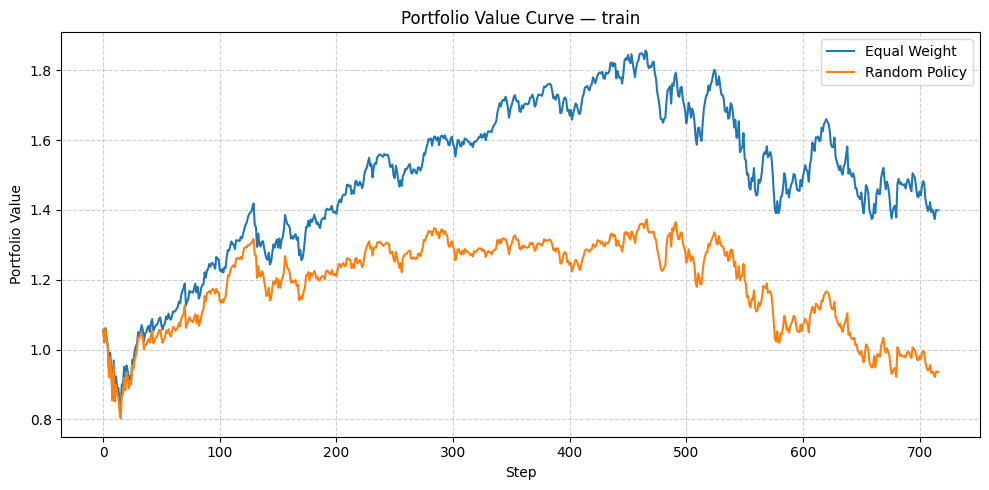

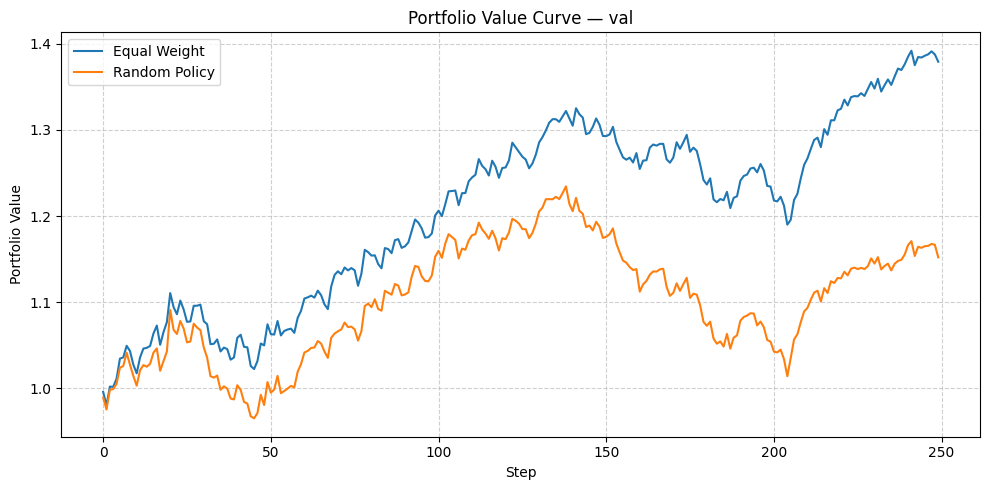

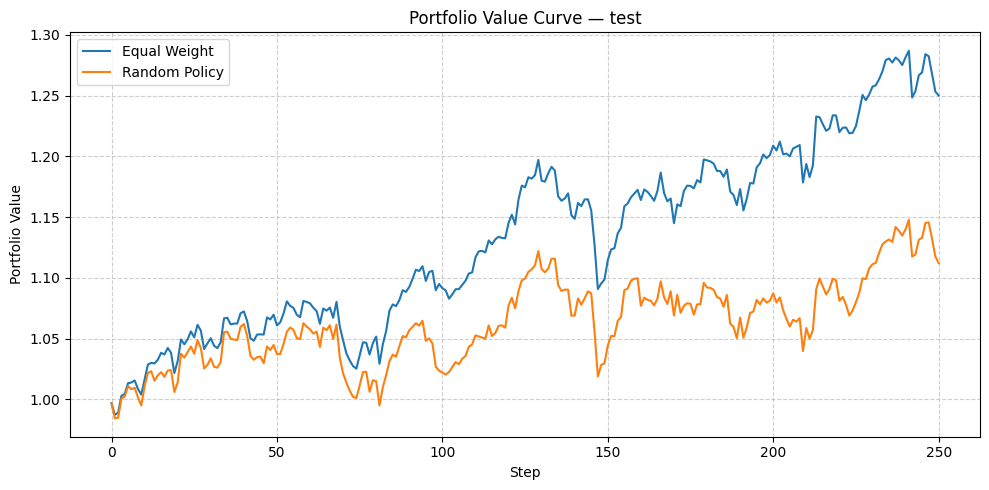

In [22]:
# ============================================================
# CELL 18 — Plot portfolio value curves
# ============================================================

def plot_portfolio_values(eq_rollouts, rand_rollouts, split_name: str):
    plt.figure(figsize=(10, 5))
    plt.plot(eq_rollouts[split_name]["portfolio_value"].values, label="Equal Weight")
    plt.plot(rand_rollouts[split_name]["portfolio_value"].values, label="Random Policy")
    plt.title(f"Portfolio Value Curve — {split_name}")
    plt.xlabel("Step")
    plt.ylabel("Portfolio Value")
    plt.legend()

    # thêm đường kẻ
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

for split_name in ["train", "val", "test"]:
    plot_portfolio_values(eq_rollouts, rand_rollouts, split_name)

In [23]:
# ============================================================
# CELL 19 — Reward mode check: cost-aware vs no-cost
# ============================================================

env_cost = PortfolioEnv(
    X=data_5y["train"]["X"][:10],
    y=data_5y["train"]["y"][:10],
    dates=data_5y["train"]["dates"][:10],
    transaction_cost=TRANSACTION_COST,
    reward_mode="cost_aware",
)

env_no_cost = PortfolioEnv(
    X=data_5y["train"]["X"][:10],
    y=data_5y["train"]["y"][:10],
    dates=data_5y["train"]["dates"][:10],
    transaction_cost=TRANSACTION_COST,
    reward_mode="no_cost",
)

rows = []
env_cost.reset()
env_no_cost.reset()

for step in range(5):
    action = sample_random_weights(len(ASSETS))

    r1 = env_cost.step(action)
    r2 = env_no_cost.step(action)

    rows.append({
        "step": step,
        "date": r1.info["date"],
        "reward_cost_aware": r1.reward,
        "reward_no_cost": r2.reward,
        "trading_cost": r1.info["trading_cost"],
        "difference_should_equal_cost": r2.reward - r1.reward,
    })

reward_check_df = pd.DataFrame(rows)
display(reward_check_df)

,step,date,reward_cost_aware,reward_no_cost,trading_cost,difference_should_equal_cost
0,0,2020-02-28,0.057835,0.058198,0.000364,0.000364
1,1,2020-03-02,-0.031138,-0.030159,0.000980,0.000980
2,2,2020-03-03,0.032794,0.033952,0.001158,0.001158
3,3,2020-03-04,-0.022029,-0.021136,0.000893,0.000893
4,4,2020-03-05,-0.021606,-0.020506,0.001100,0.001100


In [24]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=reward_check_df)

https://docs.google.com/spreadsheets/d/1CcmQ4IQoGWQKn14DIcimCjiveZ8ldwvDkqU3FIYWVQk/edit#gid=0


In [25]:
# ============================================================
# CELL 20 — Save benchmark/debug artifacts
# ============================================================

benchmark_summary_path = f"{OUTPUTS_BENCHMARK_5Y_DIR}/env_debug_benchmark_summary_5y.csv"
debug_eq_path = f"{OUTPUTS_BENCHMARK_5Y_DIR}/env_debug_equal_weight_first5_5y.csv"

benchmark_summary.to_csv(benchmark_summary_path, index=False)
debug_eq_5.to_csv(debug_eq_path, index=False)

for split_name in ["train", "val", "test"]:
    eq_rollouts[split_name].to_csv(
        f"{OUTPUTS_BENCHMARK_5Y_DIR}/equal_weight_rollout_{split_name}_5y.csv",
        index=False
    )
    rand_rollouts[split_name].to_csv(
        f"{OUTPUTS_BENCHMARK_5Y_DIR}/random_rollout_{split_name}_5y.csv",
        index=False
    )

print("Saved:", benchmark_summary_path)
print("Saved:", debug_eq_path)
print("Saved rollout csv files.")

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/benchmark_outputs_5y/env_debug_benchmark_summary_5y.csv
Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/benchmark_outputs_5y/env_debug_equal_weight_first5_5y.csv
Saved rollout csv files.


In [26]:
# ============================================================
# CELL 21 — Save env-ready artifact for training notebooks
# ============================================================

np.savez_compressed(
    f"{DATA_PROCESSED_DIR}/env_ready_5y.npz",
    X_train=data_5y["train"]["X"],
    y_train=data_5y["train"]["y"],
    dates_train=data_5y["train"]["dates"],
    X_val=data_5y["val"]["X"],
    y_val=data_5y["val"]["y"],
    dates_val=data_5y["val"]["dates"],
    X_test=data_5y["test"]["X"],
    y_test=data_5y["test"]["y"],
    dates_test=data_5y["test"]["dates"],
    assets=np.array(ASSETS),
    feature_cols=np.array(FEATURE_COLS),
)

print("Saved:", f"{DATA_PROCESSED_DIR}/env_ready_5y.npz")

Saved: /content/drive/MyDrive/thesis_rl_trading_final/data_processed/env_ready_5y.npz


In [27]:
# ============================================================
# CELL 22 — Final sanity checks
# ============================================================

assert os.path.exists(f"{DATA_PROCESSED_DIR}/tensor_bundle_5y_standardized.npz")
assert os.path.exists(f"{DATA_PROCESSED_DIR}/scaler_5y.json")
assert os.path.exists(f"{DATA_PROCESSED_DIR}/env_ready_5y.npz")
assert os.path.exists(f"{OUTPUTS_BENCHMARK_5Y_DIR}/env_debug_benchmark_summary_5y.csv")

assert data_5y["train"]["X"].shape[1:] == (LOOKBACK, len(ASSETS), len(FEATURE_COLS))
assert data_5y["val"]["X"].shape[1:] == (LOOKBACK, len(ASSETS), len(FEATURE_COLS))
assert data_5y["test"]["X"].shape[1:] == (LOOKBACK, len(ASSETS), len(FEATURE_COLS))

print("All env-debug sanity checks passed.")

All env-debug sanity checks passed.
